In [1]:
from pathlib import Path
from urllib.request import urlretrieve

PANNS_DATA_DIR = Path.home() / "panns_data"
PANNS_DATA_DIR.mkdir(parents=True, exist_ok=True)
PANNS_LABELS_PATH = PANNS_DATA_DIR / "class_labels_indices.csv"
PANNS_LABELS_URL = "https://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/class_labels_indices.csv"

if not PANNS_LABELS_PATH.exists():
    print("Downloading AudioSet labels...")
    urlretrieve(PANNS_LABELS_URL, PANNS_LABELS_PATH)
print("AudioSet labels:", PANNS_LABELS_PATH)


AudioSet labels: C:\Users\benja\panns_data\class_labels_indices.csv


In [2]:
from math import gcd
import copy, json, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import resample_poly

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from panns_inference import AudioTagging

from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix,
    f1_score, precision_score, roc_auc_score,
)


In [3]:
AUDIO_DIR = Path(".")
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
META_DIR = DATA_DIR / "metadata"
MODEL_MANIFEST_PATH = META_DIR / "benchmark_2_audio_model_manifest.csv"
MODELS_DIR = AUDIO_DIR / "models"
RESULTS_DIR = AUDIO_DIR / "results"
PRETRAINED_DIR = MODELS_DIR / "pretrained"

PANNS_CHECKPOINT_PATH = PRETRAINED_DIR / "Cnn14_mAP=0.431.pth"
PANNS_CHECKPOINT_URL = "https://zenodo.org/record/3987831/files/Cnn14_mAP%3D0.431.pth?download=1"
BASELINE_HEAD_PATH = MODELS_DIR / "panns_cnn14_binary_head_2p0s.pt"
BASELINE_CONFIG_PATH = RESULTS_DIR / "panns_cnn14_config_2p0s.json"

PANNS_SAMPLE_RATE = 32_000
CONTEXT_SECONDS = 2.0
DURATION_TOLERANCE_S = 0.05
TARGET_ANIMAL_RECALL = 0.95
RANDOM_SEED = 42
FEATURE_BATCH_SIZE = 16
TRAIN_BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 150
EARLY_STOPPING_PATIENCE = 20
EXIT1_HIDDEN_DIM = 64
EXIT2_HIDDEN_DIM = 128
EXIT_DROPOUT = 0.30

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATURE_CACHE_PATH = RESULTS_DIR / "panns_early_exit_features_2p0s.npz"
EXIT1_PATH = MODELS_DIR / "panns_exit1_block2_2p0s.pt"
EXIT2_PATH = MODELS_DIR / "panns_exit2_block4_2p0s.pt"
POLICY_RESULTS_PATH = RESULTS_DIR / "panns_early_exit_policy_results_2p0s.csv"

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(RANDOM_SEED)

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
Capability: (12, 0)


In [4]:
manifest = pd.read_csv(MODEL_MANIFEST_PATH)
required = {"sample_id","event_id","file_id","anchor_s","duration","binary_label","label_name","site_id","cam_id","audio_path","dataset_split"}
missing = required - set(manifest.columns)
assert not missing, f"Missing columns: {sorted(missing)}"
assert manifest.groupby("event_id")["dataset_split"].nunique().max() == 1
eligible = manifest[manifest["duration"] >= CONTEXT_SECONDS].copy()
print("Samples:", len(eligible), "Events:", eligible["event_id"].nunique())
display(eligible.groupby(["dataset_split","label_name"]).agg(samples=("sample_id","count"),events=("event_id","nunique")))


Samples: 908 Events: 389


samples  events
dataset_split label_name                 
test          animal          123      57
              background       84      28
train         animal          436     203
              background      120      40
val           animal          115      51
              background       30      10

In [5]:
def choose_window(anchor_s, duration_s, context_s, tolerance_s=DURATION_TOLERANCE_S):
    if duration_s < context_s - tolerance_s:
        raise ValueError(f"Source duration {duration_s:.3f}s is shorter than context {context_s:.3f}s")
    effective = max(duration_s, context_s)
    start = np.clip(anchor_s - context_s/2, 0, effective-context_s)
    return float(start), float(start+context_s)

In [6]:
def resample_waveform(waveform, source_sr, target_sr):
    if source_sr == target_sr: return waveform.astype(np.float32, copy=False)
    d = gcd(int(source_sr), int(target_sr))
    return resample_poly(waveform, up=target_sr//d, down=source_sr//d).astype(np.float32)

In [7]:
def load_panns_waveform(row, context_s=CONTEXT_SECONDS):
    path = Path(row["audio_path"])
    if not path.exists(): raise FileNotFoundError(path)
    with sf.SoundFile(path) as f:
        sr = int(f.samplerate)
        actual_duration = len(f) / sr
        duration = min(float(row["duration"]), float(actual_duration))
        start, _ = choose_window(float(row["anchor_s"]), duration, context_s)
        f.seek(round(start * sr))
        waveform = f.read(frames=round(context_s*sr), dtype="float32", always_2d=False)
    if waveform.ndim == 2: waveform = waveform.mean(axis=1)
    waveform = resample_waveform(waveform, sr, PANNS_SAMPLE_RATE)
    target = round(context_s * PANNS_SAMPLE_RATE)
    if len(waveform) > target: waveform = waveform[:target]
    elif len(waveform) < target: waveform = np.pad(waveform, (0, target-len(waveform)))
    return np.clip(waveform, -1, 1).astype(np.float32)

In [8]:
PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)
if not PANNS_CHECKPOINT_PATH.exists():
    print("Downloading Cnn14 checkpoint...")
    urlretrieve(PANNS_CHECKPOINT_URL, PANNS_CHECKPOINT_PATH)
assert BASELINE_HEAD_PATH.exists(), f"Run PANN_baseline.ipynb first: missing {BASELINE_HEAD_PATH}"

panns = AudioTagging(checkpoint_path=str(PANNS_CHECKPOINT_PATH), device="cuda" if DEVICE.type=="cuda" else "cpu")
panns_model = panns.model.module if isinstance(panns.model, torch.nn.DataParallel) else panns.model
panns_model.eval()
for p in panns_model.parameters(): p.requires_grad=False

class BinaryHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.30):
        super().__init__()
        self.network = nn.Sequential(nn.LayerNorm(input_dim), nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim,1))
    def forward(self,x): return self.network(x).squeeze(-1)

ckpt = torch.load(BASELINE_HEAD_PATH, map_location=DEVICE)
final_head = BinaryHead(ckpt["input_dim"], ckpt["hidden_dim"], ckpt["dropout"]).to(DEVICE)
final_head.load_state_dict(ckpt["head_state_dict"])
final_head.eval()
for p in final_head.parameters(): p.requires_grad=False
print("Loaded frozen backbone and frozen final head")


Checkpoint path: models\pretrained\Cnn14_mAP=0.431.pth
GPU number: 1
Loaded frozen backbone and frozen final head


In [9]:
def pool_intermediate_feature(x):
    x = torch.mean(x, dim=3)       # mean over frequency
    x_max, _ = torch.max(x, dim=2)
    x_mean = torch.mean(x, dim=2)
    return x_max + x_mean

@torch.no_grad()
def forward_shared_features(waveform_batch):
    panns_model.eval()
    x = panns_model.spectrogram_extractor(waveform_batch)
    x = panns_model.logmel_extractor(x)
    x = x.transpose(1,3); x = panns_model.bn0(x); x = x.transpose(1,3)

    x = panns_model.conv_block1(x, pool_size=(2,2), pool_type="avg")
    x = panns_model.conv_block2(x, pool_size=(2,2), pool_type="avg")
    f1 = pool_intermediate_feature(x)   # 128-D

    x = panns_model.conv_block3(x, pool_size=(2,2), pool_type="avg")
    x = panns_model.conv_block4(x, pool_size=(2,2), pool_type="avg")
    f2 = pool_intermediate_feature(x)   # 512-D

    x = panns_model.conv_block5(x, pool_size=(2,2), pool_type="avg")
    x = panns_model.conv_block6(x, pool_size=(1,1), pool_type="avg")
    x = torch.mean(x, dim=3)
    x_max, _ = torch.max(x, dim=2); x_mean = torch.mean(x, dim=2)
    ff = F.relu(panns_model.fc1(x_max + x_mean))  # 2048-D
    return f1, f2, ff


In [10]:
row = eligible.iloc[0]
wav = load_panns_waveform(row)
t = torch.from_numpy(wav[None,:]).float().to(DEVICE)
with torch.no_grad(): f1_demo, f2_demo, ff_demo = forward_shared_features(t)
_, official_embedding = panns.inference(wav[None,:])
official = torch.from_numpy(official_embedding).float().to(DEVICE)
diff = (ff_demo-official).abs().max().item()
print("Exit1:", tuple(f1_demo.shape), "Exit2:", tuple(f2_demo.shape), "Final:", tuple(ff_demo.shape))
print("Max final embedding difference:", diff)
assert diff < 1e-4, "Manual forward no longer matches baseline PANNs"


Exit1: (1, 128) Exit2: (1, 512) Final: (1, 2048)
Max final embedding difference: 0.0


In [11]:
@torch.no_grad()
def extract_all_features(df, batch_size=FEATURE_BATCH_SIZE):
    A,B,C = [],[],[]; start=time.perf_counter()
    for i in range(0,len(df),batch_size):
        bdf=df.iloc[i:i+batch_size]
        audio=np.stack([load_panns_waveform(r) for _,r in bdf.iterrows()])
        tensor=torch.from_numpy(audio).float().to(DEVICE)
        a,b,c=forward_shared_features(tensor)
        A.append(a.cpu().numpy().astype(np.float32)); B.append(b.cpu().numpy().astype(np.float32)); C.append(c.cpu().numpy().astype(np.float32))
        done=min(i+batch_size,len(df))
        if done%100 < batch_size or done==len(df): print(f"{done}/{len(df)} samples ({time.perf_counter()-start:.1f}s)")
    return np.concatenate(A),np.concatenate(B),np.concatenate(C)

sample_ids=eligible["sample_id"].astype(str).to_numpy()
if FEATURE_CACHE_PATH.exists():
    z=np.load(FEATURE_CACHE_PATH,allow_pickle=True)
    assert np.array_equal(sample_ids,z["sample_ids"].astype(str)), "Feature cache does not match manifest"
    X1,X2,Xf=z["exit1"],z["exit2"],z["final"]
    print("Loaded:", FEATURE_CACHE_PATH)
else:
    X1,X2,Xf=extract_all_features(eligible)
    np.savez_compressed(FEATURE_CACHE_PATH,sample_ids=sample_ids,exit1=X1,exit2=X2,final=Xf)
    print("Saved:", FEATURE_CACHE_PATH)
print(X1.shape,X2.shape,Xf.shape)
assert X1.shape[1]==128 and X2.shape[1]==512 and Xf.shape[1]==2048


112/908 samples (1.6s)
208/908 samples (2.5s)
304/908 samples (3.5s)
400/908 samples (4.4s)
512/908 samples (5.5s)
608/908 samples (6.3s)
704/908 samples (7.2s)
800/908 samples (8.1s)
908/908 samples (9.0s)
Saved: results\panns_early_exit_features_2p0s.npz
(908, 128) (908, 512) (908, 2048)


In [12]:
y=eligible["binary_label"].astype(np.float32).to_numpy()
s=eligible["dataset_split"].to_numpy()
train_mask=s=="train"; val_mask=s=="val"; test_mask=s=="test"
y_train,y_val,y_test=y[train_mask],y[val_mask],y[test_mask]
print("Train/val/test:",train_mask.sum(),val_mask.sum(),test_mask.sum())


Train/val/test: 556 145 207


In [13]:
def train_exit_head(Xtr,ytr,Xv,yv,input_dim,hidden_dim,save_path):
    model=BinaryHead(input_dim,hidden_dim,EXIT_DROPOUT).to(DEVICE)
    loader=DataLoader(TensorDataset(torch.from_numpy(Xtr).float(),torch.from_numpy(ytr).float()),batch_size=TRAIN_BATCH_SIZE,shuffle=True)
    pos_weight=torch.tensor([(ytr==0).sum()/(ytr==1).sum()],dtype=torch.float32,device=DEVICE)
    criterion=nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
    Xv_t=torch.from_numpy(Xv).float().to(DEVICE); yv_t=torch.from_numpy(yv).float().to(DEVICE)
    best=None; best_loss=np.inf; stale=0; hist=[]
    for epoch in range(1,MAX_EPOCHS+1):
        model.train(); total=0; seen=0
        for bx,by in loader:
            bx,by=bx.to(DEVICE),by.to(DEVICE); optimizer.zero_grad(); loss=criterion(model(bx),by); loss.backward(); optimizer.step()
            total += loss.item()*len(bx); seen += len(bx)
        model.eval()
        with torch.no_grad(): vl=criterion(model(Xv_t),yv_t).item()
        tl=total/seen; hist.append({"epoch":epoch,"train_loss":tl,"val_loss":vl})
        if vl < best_loss-1e-5: best_loss=vl; best=copy.deepcopy(model.state_dict()); stale=0
        else: stale+=1
        if epoch==1 or epoch%10==0: print(f"epoch {epoch:3d} | train={tl:.4f} | val={vl:.4f}")
        if stale>=EARLY_STOPPING_PATIENCE: print("early stopping at",epoch); break
    model.load_state_dict(best)
    torch.save({"state_dict":model.state_dict(),"input_dim":input_dim,"hidden_dim":hidden_dim,"dropout":EXIT_DROPOUT},save_path)
    return model,pd.DataFrame(hist)

print("Training Exit 1...")
exit1_head,h1=train_exit_head(X1[train_mask],y_train,X1[val_mask],y_val,128,EXIT1_HIDDEN_DIM,EXIT1_PATH)
print("\nTraining Exit 2...")
exit2_head,h2=train_exit_head(X2[train_mask],y_train,X2[val_mask],y_val,512,EXIT2_HIDDEN_DIM,EXIT2_PATH)


Training Exit 1...
epoch   1 | train=0.2819 | val=0.2620
epoch  10 | train=0.1972 | val=0.1767
epoch  20 | train=0.1568 | val=0.1538
epoch  30 | train=0.1504 | val=0.1499
epoch  40 | train=0.1392 | val=0.1517
early stopping at 45

Training Exit 2...
epoch   1 | train=0.2567 | val=0.1834
epoch  10 | train=0.0910 | val=0.1112
epoch  20 | train=0.0575 | val=0.1245
early stopping at 29


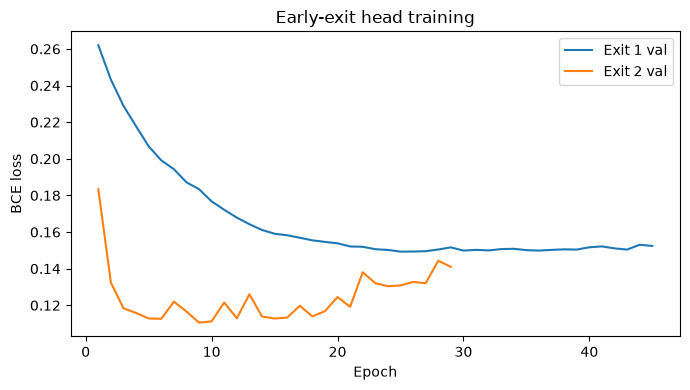

In [14]:
plt.figure(figsize=(7,4))
plt.plot(h1["epoch"],h1["val_loss"],label="Exit 1 val")
plt.plot(h2["epoch"],h2["val_loss"],label="Exit 2 val")
plt.xlabel("Epoch"); plt.ylabel("BCE loss"); plt.title("Early-exit head training"); plt.legend(); plt.tight_layout(); plt.show()


In [15]:
def predict_probabilities(model,X):
    model.eval()
    with torch.no_grad(): return torch.sigmoid(model(torch.from_numpy(X).float().to(DEVICE))).cpu().numpy()

In [16]:
p1=predict_probabilities(exit1_head,X1)
p2=predict_probabilities(exit2_head,X2)
pf=predict_probabilities(final_head,Xf)


In [17]:
def gate_metrics(y_true,p,threshold):
    yt=np.asarray(y_true).astype(int); pred=(np.asarray(p)>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(yt,pred,labels=[0,1]).ravel()
    rec=tp/(tp+fn) if tp+fn else np.nan; bg=tn/(tn+fp) if tn+fp else np.nan
    return {"accuracy":accuracy_score(yt,pred),"roc_auc":roc_auc_score(yt,p),"pr_auc":average_precision_score(yt,p),"precision_animal":precision_score(yt,pred,zero_division=0),"animal_recall":rec,"background_rejection":bg,"f1_animal":f1_score(yt,pred,zero_division=0),"tn":int(tn),"fp":int(fp),"fn":int(fn),"tp":int(tp)}


In [18]:
def threshold_for_recall(y_true,p,target=TARGET_ANIMAL_RECALL):
    rows=[]
    for t in np.unique(np.concatenate(([0.0],p,[1.0]))): rows.append({"threshold":float(t),**gate_metrics(y_true,p,t)})
    df=pd.DataFrame(rows); feasible=df[df["animal_recall"]>=target]
    best=feasible.sort_values(["background_rejection","threshold"],ascending=[False,False]).iloc[0]
    return float(best["threshold"]),df


In [19]:
t1,_=threshold_for_recall(y_val,p1[val_mask]); t2,_=threshold_for_recall(y_val,p2[val_mask])
if BASELINE_CONFIG_PATH.exists():
    t_final=float(json.loads(BASELINE_CONFIG_PATH.read_text())["selected_threshold"])
    print("Using frozen final threshold from static baseline")
else: t_final,_=threshold_for_recall(y_val,pf[val_mask])
print("Thresholds:",t1,t2,t_final)


Using frozen final threshold from static baseline
Thresholds: 0.2324143648147583 0.2000872790813446 0.16617503762245178


In [20]:
rows=[]
for name,p,t in [("Exit 1 / block 2",p1,t1),("Exit 2 / block 4",p2,t2),("Final / block 6",pf,t_final)]:
    for split,mask in [("validation",val_mask),("test",test_mask)]: rows.append({"exit":name,"split":split,"threshold":t,**gate_metrics(y[mask],p[mask],t)})
standalone=pd.DataFrame(rows)
display(standalone[["exit","split","roc_auc","pr_auc","accuracy","animal_recall","background_rejection"]].round(4))


,exit,split,roc_auc,pr_auc,accuracy,animal_recall,background_rejection
0,Exit 1 / block 2,validation,0.9267,0.9792,0.9034,0.9565,0.7000
1,Exit 1 / block 2,test,0.9497,0.9668,0.8261,0.9675,0.6190
2,Exit 2 / block 4,validation,0.9539,0.9877,0.9172,0.9565,0.7667
3,Exit 2 / block 4,test,0.9714,0.9779,0.9275,0.9756,0.8571
4,Final / block 6,validation,0.8867,0.9696,0.8414,0.9565,0.4000
5,Final / block 6,test,0.9432,0.9626,0.8261,0.9512,0.6429


In [21]:
def safe_logit(p,eps=1e-6):
    p=np.clip(p,eps,1-eps); return np.log(p/(1-p))


In [22]:
def simulate_policy(y_true,p1_,p2_,pf_,m1,m2):
    y_true=np.asarray(y_true).astype(int); pred=np.empty(len(y_true),int); stage=np.empty(len(y_true),int)
    s1=safe_logit(p1_)-safe_logit(t1); s2=safe_logit(p2_)-safe_logit(t2)
    for i in range(len(y_true)):
        if s1[i] <= -m1: pred[i]=0; stage[i]=1
        elif s1[i] >= m1: pred[i]=1; stage[i]=1
        elif s2[i] <= -m2: pred[i]=0; stage[i]=2
        elif s2[i] >= m2: pred[i]=1; stage[i]=2
        else: pred[i]=int(pf_[i]>=t_final); stage[i]=3
    tn,fp,fn,tp=confusion_matrix(y_true,pred,labels=[0,1]).ravel()
    rec=tp/(tp+fn) if tp+fn else np.nan; bg=tn/(tn+fp) if tn+fp else np.nan
    r1=(stage==1).mean(); r2=(stage==2).mean(); rf=(stage==3).mean()
    return {"accuracy":accuracy_score(y_true,pred),"animal_recall":rec,"background_rejection":bg,"f1_animal":f1_score(y_true,pred,zero_division=0),"exit1_rate":r1,"exit2_rate":r2,"final_rate":rf,"avg_blocks_executed":2*r1+4*r2+6*rf,"tn":int(tn),"fp":int(fp),"fn":int(fn),"tp":int(tp)}


In [23]:
MARGIN_GRID=[0.25,0.5,0.75,1.0,1.5,2.0,2.5,3.0]
policy_rows=[]
for m1 in MARGIN_GRID:
    for m2 in MARGIN_GRID: policy_rows.append({"margin1":m1,"margin2":m2,**simulate_policy(y_val,p1[val_mask],p2[val_mask],pf[val_mask],m1,m2)})
val_policies=pd.DataFrame(policy_rows)
feasible=val_policies[val_policies["animal_recall"]>=TARGET_ANIMAL_RECALL].sort_values(["avg_blocks_executed","accuracy"],ascending=[True,False]).reset_index(drop=True)
print("Feasible validation policies:",len(feasible))
display(feasible.head(15).round(4))


Feasible validation policies: 58


,margin1,margin2,accuracy,animal_recall,background_rejection,f1_animal,exit1_rate,exit2_rate,final_rate,avg_blocks_executed,tn,fp,fn,tp
0,0.25,0.25,0.9034,0.9565,0.7000,0.9402,0.931,0.0621,0.0069,2.1517,21,9,5,110
1,0.25,0.50,0.8966,0.9565,0.6667,0.9362,0.931,0.0552,0.0138,2.1655,20,10,5,110
2,0.25,0.75,0.8966,0.9565,0.6667,0.9362,0.931,0.0552,0.0138,2.1655,20,10,5,110
3,0.25,1.00,0.8966,0.9565,0.6667,0.9362,0.931,0.0483,0.0207,2.1793,20,10,5,110
4,0.25,1.50,0.8966,0.9565,0.6667,0.9362,0.931,0.0276,0.0414,2.2207,20,10,5,110
5,0.25,2.00,0.8966,0.9565,0.6667,0.9362,0.931,0.0276,0.0414,2.2207,20,10,5,110
6,0.25,2.50,0.8966,0.9565,0.6667,0.9362,0.931,0.0276,0.0414,2.2207,20,10,5,110
7,0.25,3.00,0.8966,0.9565,0.6667,0.9362,0.931,0.0207,0.0483,2.2345,20,10,5,110
8,0.50,0.25,0.9034,0.9652,0.6667,0.9407,0.869,0.1103,0.0207,2.3034,20,10,4,111
9,0.50,0.50,0.8966,0.9652,0.6333,0.9367,0.869,0.0897,0.0414,2.3448,19,11,4,111


In [24]:
if len(feasible)<3: raise RuntimeError("Fewer than 3 policies meet the target validation recall. Inspect standalone exits.")
feasible=feasible.sort_values("avg_blocks_executed").reset_index(drop=True)
idx=[0,len(feasible)//2,len(feasible)-1]
selected=feasible.iloc[idx].copy(); selected["operating_point"]=["aggressive","balanced","conservative"]
display(selected[["operating_point","margin1","margin2","accuracy","animal_recall","background_rejection","exit1_rate","exit2_rate","final_rate","avg_blocks_executed"]].round(4))

test_rows=[]
for _,r in selected.iterrows():
    test_rows.append({"operating_point":r["operating_point"],"margin1":r["margin1"],"margin2":r["margin2"],**simulate_policy(y_test,p1[test_mask],p2[test_mask],pf[test_mask],float(r["margin1"]),float(r["margin2"]))})
test_policies=pd.DataFrame(test_rows)
display(test_policies[["operating_point","accuracy","animal_recall","background_rejection","exit1_rate","exit2_rate","final_rate","avg_blocks_executed","tn","fp","fn","tp"]].round(4))


,operating_point,margin1,margin2,accuracy,animal_recall,background_rejection,exit1_rate,exit2_rate,final_rate,avg_blocks_executed
0,aggressive,0.25,0.25,0.9034,0.9565,0.7000,0.9310,0.0621,0.0069,2.1517
29,balanced,2.00,0.25,0.9172,0.9652,0.7333,0.5655,0.3931,0.0414,2.9517
57,conservative,3.00,3.00,0.8759,0.9565,0.5667,0.4966,0.1931,0.3103,3.6276


,operating_point,accuracy,animal_recall,background_rejection,exit1_rate,exit2_rate,final_rate,avg_blocks_executed,tn,fp,fn,tp
0,aggressive,0.8792,0.9837,0.7262,0.8889,0.1063,0.0048,2.2319,61,23,2,121
1,balanced,0.9324,0.9837,0.8571,0.4976,0.4976,0.0048,3.0145,72,12,2,121
2,conservative,0.8502,0.9512,0.7024,0.4106,0.1932,0.3961,3.9710,59,25,6,117


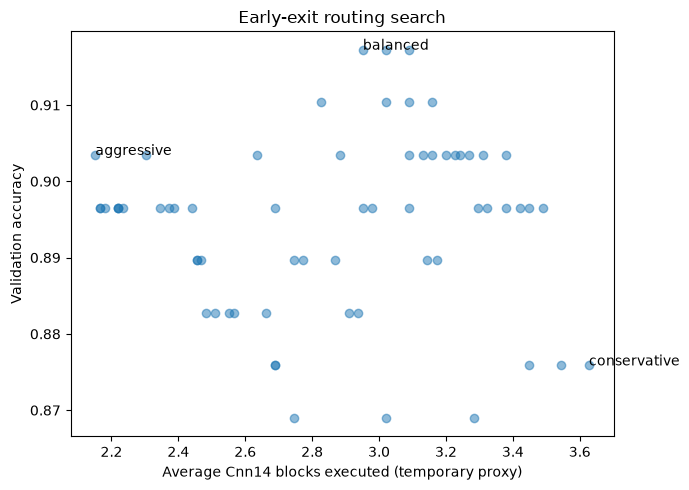

In [25]:
plt.figure(figsize=(7,5))
plt.scatter(val_policies["avg_blocks_executed"],val_policies["accuracy"],alpha=.5)
for _,r in selected.iterrows(): plt.annotate(r["operating_point"],(r["avg_blocks_executed"],r["accuracy"]))
plt.xlabel("Average Cnn14 blocks executed (temporary proxy)"); plt.ylabel("Validation accuracy"); plt.title("Early-exit routing search"); plt.tight_layout(); plt.show()


In [26]:
@torch.no_grad()
def adaptive_predict_one(waveform_np, margin1, margin2):
    panns_model.eval(); exit1_head.eval(); exit2_head.eval(); final_head.eval()
    w=torch.from_numpy(waveform_np[None,:]).float().to(DEVICE)
    x=panns_model.spectrogram_extractor(w); x=panns_model.logmel_extractor(x); x=x.transpose(1,3); x=panns_model.bn0(x); x=x.transpose(1,3)
    x=panns_model.conv_block1(x,pool_size=(2,2),pool_type="avg"); x=panns_model.conv_block2(x,pool_size=(2,2),pool_type="avg")
    q1=torch.sigmoid(exit1_head(pool_intermediate_feature(x))).item(); s1=safe_logit(q1)-safe_logit(t1)
    if s1<=-margin1: return {"prediction":0,"probability":q1,"exit_stage":1}
    if s1>= margin1: return {"prediction":1,"probability":q1,"exit_stage":1}
    x=panns_model.conv_block3(x,pool_size=(2,2),pool_type="avg"); x=panns_model.conv_block4(x,pool_size=(2,2),pool_type="avg")
    q2=torch.sigmoid(exit2_head(pool_intermediate_feature(x))).item(); s2=safe_logit(q2)-safe_logit(t2)
    if s2<=-margin2: return {"prediction":0,"probability":q2,"exit_stage":2}
    if s2>= margin2: return {"prediction":1,"probability":q2,"exit_stage":2}
    x=panns_model.conv_block5(x,pool_size=(2,2),pool_type="avg"); x=panns_model.conv_block6(x,pool_size=(1,1),pool_type="avg")
    x=torch.mean(x,dim=3); xm,_=torch.max(x,dim=2); xa=torch.mean(x,dim=2); emb=F.relu(panns_model.fc1(xm+xa))
    qf=torch.sigmoid(final_head(emb)).item()
    return {"prediction":int(qf>=t_final),"probability":qf,"exit_stage":3}

balanced=selected[selected["operating_point"]=="balanced"].iloc[0]
demo=eligible.iloc[0]
result=adaptive_predict_one(load_panns_waveform(demo),float(balanced["margin1"]),float(balanced["margin2"]))
print("True label:",demo["label_name"]); print("Adaptive result:",result)


True label: animal
Adaptive result: {'prediction': 1, 'probability': 0.6118773818016052, 'exit_stage': 2}


In [27]:
val_out=selected.copy(); val_out["split"]="validation"
test_out=test_policies.copy(); test_out["split"]="test"
pd.concat([val_out,test_out],ignore_index=True,sort=False).to_csv(POLICY_RESULTS_PATH,index=False)
standalone.to_csv(RESULTS_DIR/"panns_early_exit_standalone_2p0s.csv",index=False)
print("Saved:",POLICY_RESULTS_PATH)


Saved: results\panns_early_exit_policy_results_2p0s.csv
